# Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller,acf, pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from pylab import rcParams

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pickle


import warnings
warnings.filterwarnings('ignore')


# Prepare data for forecasting

In [22]:
df_order_details = pd.read_csv("/content/orderDetails.csv")
df_order_master = pd.read_csv("/content/orderMasters.csv")
df_products = pd.read_csv("/content/products.csv")

In [23]:
df = pd.merge(df_order_details, df_order_master, how='inner', on='OrderID')

In [24]:
df = pd.merge(df, df_products, how='inner', on='ProductID')

In [25]:
df

,OrderDetailID,OrderID,ProductID,Product_Qty,Review_Star,PriceChange_x,CustomerID,Order_Date,Order_Status,EmployeeID,ManagerID,Order_TimeStart,Order_TimeEnd,ProductCategoryID,Product_Name,Product_Size,Product_UnitPrice,Product_Availability,PriceChange_y
0,1,1,P10M,9,1,0,C11029,6/2/2022,Finished,108,1,6:00:00,6:10:00,PC1,Hot Chocolate,M,18,1,20
1,13,3,P10M,4,5,0,C11002,6/2/2022,Finished,108,1,6:13:00,6:27:00,PC1,Hot Chocolate,M,18,1,20
2,19,5,P10M,9,3,0,C11009,6/2/2022,Finished,104,1,6:27:00,6:40:00,PC1,Hot Chocolate,M,18,1,20
3,91,24,P10M,10,3,0,C11095,6/2/2022,Finished,109,1,8:44:00,8:56:00,PC1,Hot Chocolate,M,18,1,20
4,110,29,P10M,6,2,0,C11011,6/2/2022,Finished,109,1,9:02:00,9:11:00,PC1,Hot Chocolate,M,18,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301970,274438,73188,P18M,1,5,0,C12468,6/22/2023,Finished,125,3,11:32:00,11:44:00,PC3,Vanilla Bean Frappuccino,M,25,1,20
301971,281304,74971,P18M,1,5,20,C12433,6/30/2023,Finished,112,2,23:20:00,23:35:00,PC3,Vanilla Bean Frappuccino,M,25,1,20
301972,290122,77294,P18M,1,4,0,C12906,7/14/2023,Finished,117,2,6:33:00,6:41:00,PC3,Vanilla Bean Frappuccino,M,25,1,20
301973,297342,79245,P18M,1,3,0,C12428,7/24/2023,Finished,124,3,10:53:00,11:05:00,PC3,Vanilla Bean Frappuccino,M,25,1,20


In [27]:
df.columns

Index(['OrderDetailID', 'OrderID', 'ProductID', 'Product_Qty', 'Review_Star',
       'PriceChange_x', 'CustomerID', 'Order_Date', 'Order_Status',
       'EmployeeID', 'ManagerID', 'Order_TimeStart', 'Order_TimeEnd',
       'ProductCategoryID', 'Product_Name', 'Product_Size',
       'Product_UnitPrice', 'Product_Availability', 'PriceChange_y'],
      dtype='object')

In [28]:
df.drop(columns=['OrderDetailID', 'OrderID', 'Review_Star', 'CustomerID', 'EmployeeID',
       'ManagerID', 'Order_TimeEnd', 'ProductCategoryID', 'Product_Name', 'Product_Size', 'Product_Availability', 'PriceChange_y'], inplace=True)

In [29]:
df = df[df['Order_Status']=='Finished']

In [30]:
df.shape

(301933, 7)

In [31]:
df.drop(columns=['Order_Status'], inplace=True)

In [32]:
df

,ProductID,Product_Qty,PriceChange_x,Order_Date,Order_TimeStart,Product_UnitPrice
0,P10M,9,0,6/2/2022,6:00:00,18
1,P10M,4,0,6/2/2022,6:13:00,18
2,P10M,9,0,6/2/2022,6:27:00,18
3,P10M,10,0,6/2/2022,8:44:00,18
4,P10M,6,0,6/2/2022,9:02:00,18
...,...,...,...,...,...,...
301970,P18M,1,0,6/22/2023,11:32:00,25
301971,P18M,1,20,6/30/2023,23:20:00,25
301972,P18M,1,0,7/14/2023,6:33:00,25
301973,P18M,1,0,7/24/2023,10:53:00,25


In [33]:
# Merge the 'Order_Date' and 'Order_TimeStart' columns
df['Order_DateTime'] = df['Order_Date'] + ' ' + df['Order_TimeStart']

# Drop the original 'Order_Date' and 'Order_TimeStart' columns
df = df.drop(columns=['Order_Date', 'Order_TimeStart'])

In [34]:
df

,ProductID,Product_Qty,PriceChange_x,Product_UnitPrice,Order_DateTime
0,P10M,9,0,18,6/2/2022 6:00:00
1,P10M,4,0,18,6/2/2022 6:13:00
2,P10M,9,0,18,6/2/2022 6:27:00
3,P10M,10,0,18,6/2/2022 8:44:00
4,P10M,6,0,18,6/2/2022 9:02:00
...,...,...,...,...,...
301970,P18M,1,0,25,6/22/2023 11:32:00
301971,P18M,1,20,25,6/30/2023 23:20:00
301972,P18M,1,0,25,7/14/2023 6:33:00
301973,P18M,1,0,25,7/24/2023 10:53:00


In [38]:
# Convert Order_DateTime to datetime
df['Order_DateTime'] = pd.to_datetime(df['Order_DateTime'])

# Round down to the nearest hour
df['Order_DateTime'] = df['Order_DateTime'].dt.floor('H')

In [39]:
df

,ProductID,Product_Qty,PriceChange_x,Product_UnitPrice,Order_DateTime
0,P10M,9,0,18,2022-06-02 06:00:00
1,P10M,4,0,18,2022-06-02 06:00:00
2,P10M,9,0,18,2022-06-02 06:00:00
3,P10M,10,0,18,2022-06-02 08:00:00
4,P10M,6,0,18,2022-06-02 09:00:00
...,...,...,...,...,...
301970,P18M,1,0,25,2023-06-22 11:00:00
301971,P18M,1,20,25,2023-06-30 23:00:00
301972,P18M,1,0,25,2023-07-14 06:00:00
301973,P18M,1,0,25,2023-07-24 10:00:00


In [40]:
df.columns

Index(['ProductID', 'Product_Qty', 'PriceChange_x', 'Product_UnitPrice',
       'Order_DateTime'],
      dtype='object')

In [48]:
# Convert Order_DateTime to datetime
df['Order_DateTime'] = pd.to_datetime(df['Order_DateTime'])

# Calculate the Total_Revenue for each row
df['Total_Revenue'] = df['Product_Qty'] * df['Product_UnitPrice'] * (100 - df['PriceChange_x']) / 100

# Group by ProductID and Order_DateTime, and calculate the required sums
grouped_df = df.groupby(['ProductID', 'Order_DateTime']).agg(
    Product_Qty_Sum=('Product_Qty', 'sum'),
    Total_Revenue_Sum=('Total_Revenue', 'sum')
).reset_index()

In [49]:
grouped_df

,ProductID,Order_DateTime,Product_Qty_Sum,Total_Revenue_Sum
0,P10L,2022-06-02 07:00:00,13,299.0
1,P10L,2022-06-02 10:00:00,10,230.0
2,P10L,2022-06-02 11:00:00,10,230.0
3,P10L,2022-06-02 12:00:00,5,115.0
4,P10L,2022-06-02 14:00:00,1,23.0
...,...,...,...,...
153814,P9L,2023-07-30 17:00:00,12,300.0
153815,P9L,2023-07-30 18:00:00,5,125.0
153816,P9L,2023-07-30 19:00:00,7,175.0
153817,P9L,2023-07-30 20:00:00,7,175.0


In [43]:
grouped_df.to_csv('forecastHourlyDataset.csv')

**[HOURLY PRODUCT SALES AMOUNT]**

In [50]:
df_revenue = grouped_df.drop(columns=['ProductID', 'Product_Qty_Sum'])

In [51]:
df_revenue.columns

Index(['Order_DateTime', 'Total_Revenue_Sum'], dtype='object')

In [52]:
df_revenue.shape

(153819, 2)

In [54]:
df_revenue

,Order_DateTime,Total_Revenue_Sum
0,2022-06-02 07:00:00,299.0
1,2022-06-02 10:00:00,230.0
2,2022-06-02 11:00:00,230.0
3,2022-06-02 12:00:00,115.0
4,2022-06-02 14:00:00,23.0
...,...,...
153814,2023-07-30 17:00:00,300.0
153815,2023-07-30 18:00:00,125.0
153816,2023-07-30 19:00:00,175.0
153817,2023-07-30 20:00:00,175.0


In [55]:
df_revenue['Order_DateTime'].nunique()

7526

In [57]:
# Convert Order_DateTime to datetime
df_revenue['Order_DateTime'] = pd.to_datetime(df_revenue['Order_DateTime'])

# Group by Order_DateTime and sum the Total_Revenue_Sum
df_revenue = df_revenue.groupby('Order_DateTime').agg(
    Total_Revenue_Sum=('Total_Revenue_Sum', 'sum')
).reset_index()

In [58]:
df_revenue

,Order_DateTime,Total_Revenue_Sum
0,2022-06-02 06:00:00,4001.0
1,2022-06-02 07:00:00,3923.0
2,2022-06-02 08:00:00,6348.0
3,2022-06-02 09:00:00,4397.0
4,2022-06-02 10:00:00,6441.0
...,...,...
7521,2023-07-30 17:00:00,4137.0
7522,2023-07-30 18:00:00,3894.0
7523,2023-07-30 19:00:00,4704.0
7524,2023-07-30 20:00:00,2304.0


In [59]:
df_revenue.to_csv('df_revenue.csv')

**[HOURLY PRODUCT SALES QUANTITY]**

In [61]:
df_qty = grouped_df.drop(columns=['ProductID', 'Total_Revenue_Sum'])

In [62]:
df_qty

,Order_DateTime,Product_Qty_Sum
0,2022-06-02 07:00:00,13
1,2022-06-02 10:00:00,10
2,2022-06-02 11:00:00,10
3,2022-06-02 12:00:00,5
4,2022-06-02 14:00:00,1
...,...,...
153814,2023-07-30 17:00:00,12
153815,2023-07-30 18:00:00,5
153816,2023-07-30 19:00:00,7
153817,2023-07-30 20:00:00,7


In [63]:
# Convert Order_DateTime to datetime
df_qty['Order_DateTime'] = pd.to_datetime(df_qty['Order_DateTime'])

# Group by Order_DateTime and sum the Total_Revenue_Sum
df_qty = df_qty.groupby('Order_DateTime').agg(
    Product_Qty_Sum=('Product_Qty_Sum', 'sum')
).reset_index()

In [64]:
df_qty.shape

(7526, 2)

In [65]:
df_qty.to_csv('df_qty.csv')

# EDA

In [ ]:
df_trend = df.copy()
df_trend['Order_DateTime'] = pd.to_datetime(df_trend['Order_DateTime'])

# Extract Year-Month
df_trend['YearMonth'] = df_trend['Order_DateTime'].dt.to_period('M')
df_trend['Year'] = df_trend['Order_DateTime'].dt.to_period('Y')

# Group by Year-Month and sum TotalAmount
monthly_totals = df_trend.groupby(['Year','YearMonth'])['Total_amount_per_day'].sum().reset_index()

# Optional: Convert YearMonth back to string for display purposes
monthly_totals['YearMonth'] = monthly_totals['YearMonth'].astype(str)
monthly_totals['Year'] = monthly_totals['Year'].astype(str)

# Display the result
print(monthly_totals)

    Year YearMonth  Total_amount_per_day
0   2022   2022-06             2890817.4
1   2022   2022-07             2764466.0
2   2022   2022-08             2541519.0
3   2022   2022-09             2892736.2
4   2022   2022-10             2892930.0
5   2022   2022-11             2694426.6
6   2022   2022-12             2688792.9
7   2023   2023-01             3654114.0
8   2023   2023-02             2307970.0
9   2023   2023-03             2653483.5
10  2023   2023-04             2862442.0
11  2023   2023-05             2725826.0
12  2023   2023-06             2971183.0
13  2023   2023-07             2760362.0


In [ ]:
#The fluctuation of sales
plt.figure(figsize=(15,6))
sns.lineplot(x=monthly_totals['YearMonth'], y=monthly_totals['Order_DateTime'])
plt.title("Total Sales Over Year")

KeyError: 'Order_DateTime'

<Figure size 1500x600 with 0 Axes>

In [ ]:
#Trends in each year
plt.figure(figsize=(15,6))
sns.lineplot(x=monthly_totals['YearMonth'], y=monthly_totals['Total_amount'], hue=monthly_totals['Year'])

In [ ]:
df_test = df.copy()

df_test['Order_Date'] = pd.to_datetime(df_test['Order_Date'])

# Set Order_Date as the index
df_test.set_index('Order_Date', inplace=True)

# Aggregate Total_amount by Order_Date
df_test_aggregated = df_test['Total_amount'].resample('W').sum()

## Autocorrelation function

In [ ]:
# Plot the autocorrelation function for Total_amount
plt.figure(figsize=(10, 6))
plot_acf(df_test_aggregated, lags=20)
plt.title('Autocorrelation Function for Total_amount')
plt.show()

## Total amount over time (unit:weak)

In [ ]:
# Calculate rolling mean and standard deviation
rolling_mean = df_test_aggregated.rolling(window=12).mean()
rolling_std = df_test_aggregated.rolling(window=12).std()

# Plot rolling statistics
plt.figure(figsize=(12, 6))
plt.plot(df_test_aggregated, label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean')
plt.plot(rolling_std, color='black', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()


## ADF, KPSS test

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF Test
adf_result = adfuller(df_test_aggregated)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

# KPSS Test
kpss_result = kpss(df_test_aggregated, regression='c')
print('KPSS Statistic:', kpss_result[0])
print('p-value:', kpss_result[1])
print('Critical Values:', kpss_result[3])


## Correlation with dependence variable

In [ ]:
df_corr = df.copy()
df_corr['Order_Date'] = pd.to_datetime(df_corr['Order_Date'])
df_corr['ProductSize'] = df_corr['ProductSize'].map({"M": 1, "L":2})

def time_to_minutes(t):
    try:
        h, m, s = map(int, t.strip().split(':'))
        return h * 60 + m + s / 60  # Include seconds in the conversion
    except ValueError:
        return np.nan  # or handle differently, e.g., logging an error

df_corr['Order_TimeStart'] = df_corr['Order_TimeStart'].apply(time_to_minutes)
df_corr['Order_TimeEnd'] = df_corr['Order_TimeEnd'].apply(time_to_minutes)

# Encode ProductID if needed (example with label encoding)
df_corr['ProductID'] = df_corr['ProductID'].astype('category').cat.codes

# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

**MAYBE HOURLY** *văn bản in nghiêng*

# Preprocessing

WITH SALES AMOUNT

In [66]:
df_revenue.head()

,Order_DateTime,Total_Revenue_Sum
0,2022-06-02 06:00:00,4001.0
1,2022-06-02 07:00:00,3923.0
2,2022-06-02 08:00:00,6348.0
3,2022-06-02 09:00:00,4397.0
4,2022-06-02 10:00:00,6441.0


In [67]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF Test
adf_result = adfuller(df_revenue['Total_Revenue_Sum'])
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

# KPSS Test
kpss_result = kpss(df_revenue['Total_Revenue_Sum'], regression='c')
print('KPSS Statistic:', kpss_result[0])
print('p-value:', kpss_result[1])
print('Critical Values:', kpss_result[3])


ADF Statistic: -7.974476879597053
p-value: 2.7255784918946593e-12
Critical Values: {'1%': -3.431223370165208, '5%': -2.861925963417994, '10%': -2.56697544392969}
KPSS Statistic: 0.20222658931397097
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


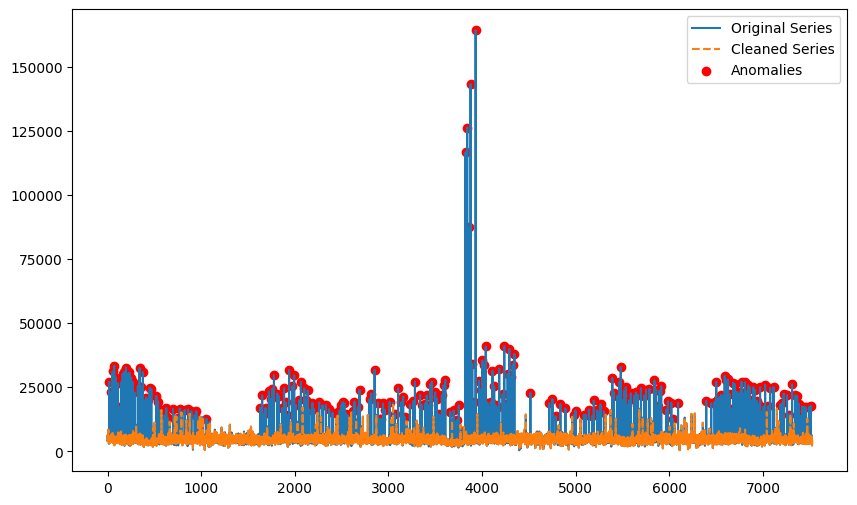

In [68]:
import pandas as pd
import numpy as np

# Assume `time_series` is your pandas Series with the time-series data
# Calculate the rolling mean and standard deviation
rolling_mean = df_revenue['Total_Revenue_Sum'].rolling(window=12).mean()
rolling_std = df_revenue['Total_Revenue_Sum'].rolling(window=12).std()

# Calculate Z-scores
z_scores = (df_revenue['Total_Revenue_Sum'] - rolling_mean) / rolling_std

# Identify anomalies (e.g., points where |Z| > 3)
anomalies = df_revenue['Total_Revenue_Sum'][np.abs(z_scores) > 3]

# Optionally, replace anomalies with NaN or interpolate
time_series_cleaned = df_revenue['Total_Revenue_Sum'].copy()
time_series_cleaned[np.abs(z_scores) > 3] = np.nan
time_series_cleaned = time_series_cleaned.interpolate()

# Visualize the anomalies
plt.figure(figsize=(10, 6))
plt.plot(df_revenue['Total_Revenue_Sum'], label='Original Series')
plt.plot(time_series_cleaned, label='Cleaned Series', linestyle='--')
plt.scatter(anomalies.index, anomalies, color='red', label='Anomalies')
plt.legend()
plt.show()


WITH SALES QUANTITY

In [69]:
df_qty.head()

,Order_DateTime,Product_Qty_Sum
0,2022-06-02 06:00:00,162
1,2022-06-02 07:00:00,160
2,2022-06-02 08:00:00,248
3,2022-06-02 09:00:00,167
4,2022-06-02 10:00:00,260


In [70]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF Test
adf_result = adfuller(df_qty['Product_Qty_Sum'])
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

# KPSS Test
kpss_result = kpss(df_qty['Product_Qty_Sum'], regression='c')
print('KPSS Statistic:', kpss_result[0])
print('p-value:', kpss_result[1])
print('Critical Values:', kpss_result[3])


ADF Statistic: -8.17960474862641
p-value: 8.19887604131496e-13
Critical Values: {'1%': -3.431223370165208, '5%': -2.861925963417994, '10%': -2.56697544392969}
KPSS Statistic: 0.3640056740122169
p-value: 0.09266996809818237
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


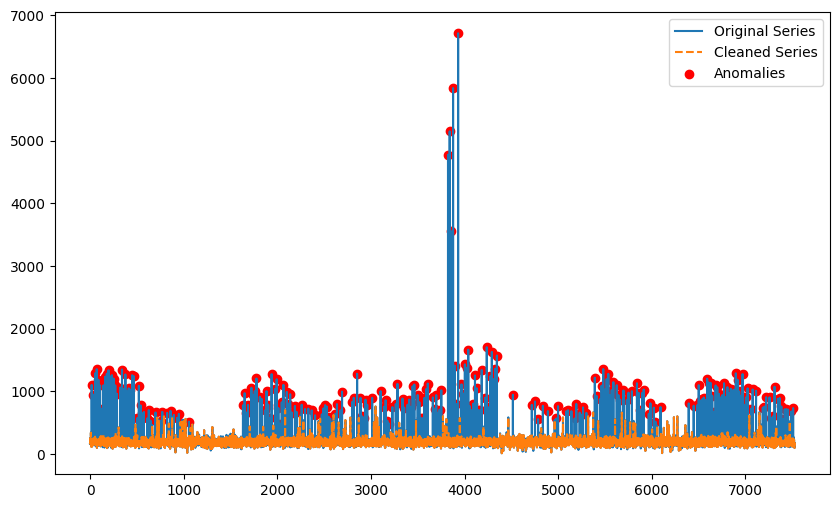

In [72]:
import pandas as pd
import numpy as np

# Assume `time_series` is your pandas Series with the time-series data
# Calculate the rolling mean and standard deviation
rolling_mean = df_qty['Product_Qty_Sum'].rolling(window=12).mean()
rolling_std = df_qty['Product_Qty_Sum'].rolling(window=12).std()

# Calculate Z-scores
z_scores = (df_qty['Product_Qty_Sum'] - rolling_mean) / rolling_std

# Identify anomalies (e.g., points where |Z| > 3)
anomalies = df_qty['Product_Qty_Sum'][np.abs(z_scores) > 3]

# Optionally, replace anomalies with NaN or interpolate
time_series_cleaned = df_qty['Product_Qty_Sum'].copy()
time_series_cleaned[np.abs(z_scores) > 3] = np.nan
time_series_cleaned = time_series_cleaned.interpolate()

# Visualize the anomalies
plt.figure(figsize=(10, 6))
plt.plot(df_qty['Product_Qty_Sum'], label='Original Series')
plt.plot(time_series_cleaned, label='Cleaned Series', linestyle='--')
plt.scatter(anomalies.index, anomalies, color='red', label='Anomalies')
plt.legend()
plt.show()


# Train model

In [73]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

## ARIMA

WITH SALES QUANTITY

In [74]:
df_revenue.columns

Index(['Order_DateTime', 'Total_Revenue_Sum'], dtype='object')

In [75]:
train_size = int(len(df_revenue) * 0.8)
train, test = df_revenue['Total_Revenue_Sum'][:train_size], df_revenue['Total_Revenue_Sum'][train_size:]

In [76]:
new_train, new_test = time_series_cleaned[:train_size], time_series_cleaned[train_size:]

In [77]:
train

0       4001.0
1       3923.0
2       6348.0
3       4397.0
4       6441.0
         ...  
6015    4198.0
6016    2397.0
6017    4153.0
6018    4607.0
6019    5534.0
Name: Total_Revenue_Sum, Length: 6020, dtype: float64

In [78]:
ARIMAmodel = ARIMA(train, order=(1, 0, 3))
fit = ARIMAmodel.fit()

forecast = fit.forecast(steps=len(test))

# Convert to numpy array for evaluation
forecast = np.array(forecast)
test_values = np.array(test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Calculate metrics
rmse = mean_squared_error(test_values, forecast, squared=False)
mae = mean_absolute_error(test_values, forecast)
mape = mean_absolute_percentage_error(test_values, forecast)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MAPE: {mape}')

RMSE: 3492.6325689374194
MAE: 1653.620066253002
MAPE: 0.3047952095578754


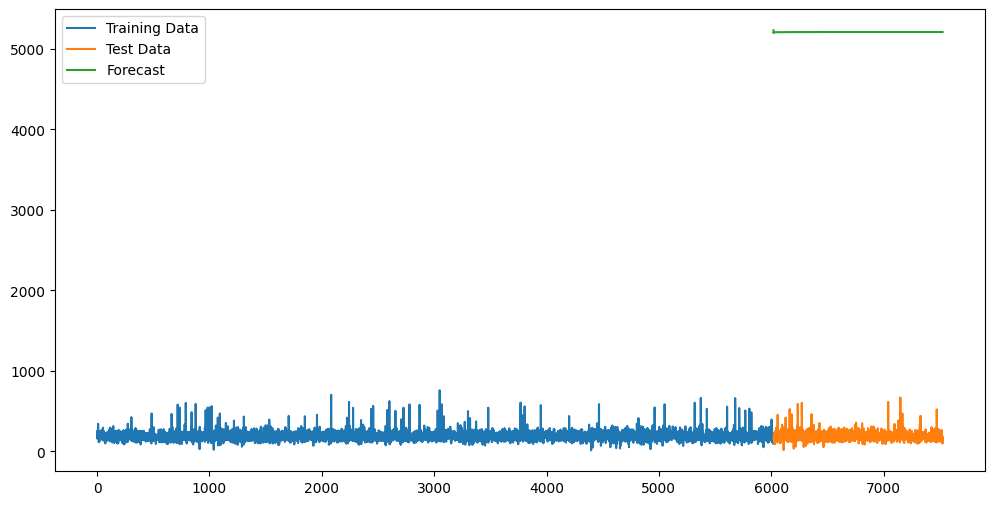

In [79]:
plt.figure(figsize=(12, 6))
plt.plot(new_train, label='Training Data')
plt.plot(new_test, label='Test Data')
plt.plot(new_test.index, forecast, label='Forecast')
plt.legend()
plt.show()

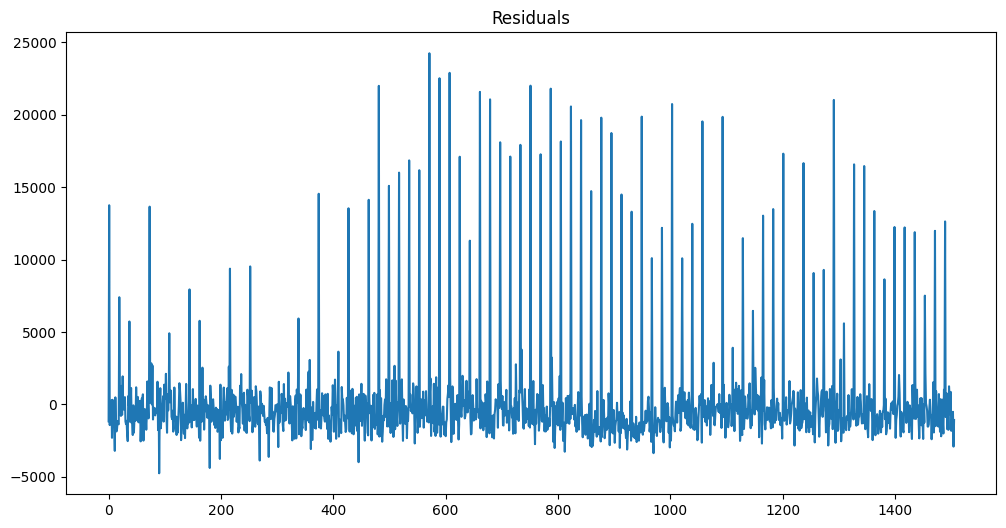

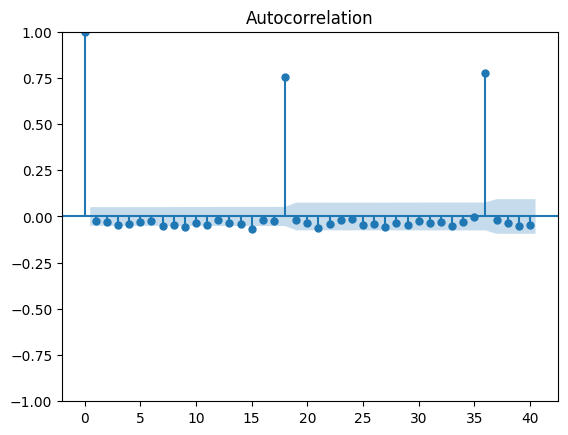

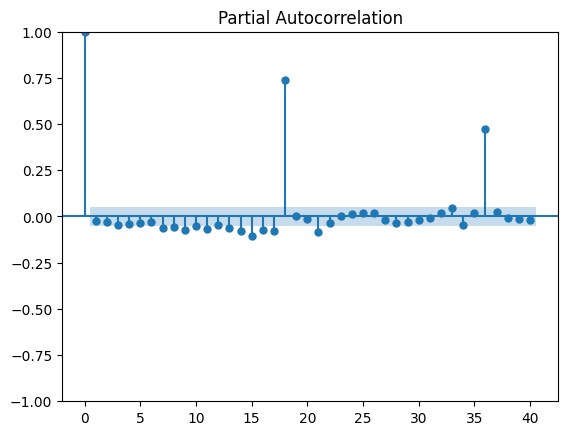

In [80]:
residuals = test_values - forecast
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('Residuals')
plt.show()

import statsmodels.api as sm
sm.graphics.tsa.plot_acf(residuals, lags=40)
sm.graphics.tsa.plot_pacf(residuals, lags=40)
plt.show()

[link text](https://)## Exponential Smoothing

In [81]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ESmodel = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12)
fit = ESmodel.fit()

forecast = fit.forecast(steps=len(test))

# Convert to numpy array for evaluation
forecast = np.array(forecast)
test_values = np.array(test)

rmse = mean_squared_error(test_values, forecast, squared=False)
mae = mean_absolute_error(test_values, forecast)
mape = mean_absolute_percentage_error(test_values, forecast)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MAPE: {mape}')

RMSE: 5513.432593709336
MAE: 4226.929110753617
MAPE: 0.8149303096602255


In [100]:
# Convert Order_DateTime to datetime
df_revenue['Order_DateTime'] = pd.to_datetime(df_revenue['Order_DateTime'])

# Extract year, month, day, and hour from Order_DateTime
df_revenue['Year'] = df_revenue['Order_DateTime'].dt.year
df_revenue['Month'] = df_revenue['Order_DateTime'].dt.month
df_revenue['Day'] = df_revenue['Order_DateTime'].dt.day
df_revenue['Hour'] = df_revenue['Order_DateTime'].dt.hour

# Prepare the data for the model with additional features
X = df_revenue[['Year', 'Month', 'Day', 'Hour']]
y = df_revenue['Total_Revenue_Sum']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Holt-Winters Exponential Smoothing model
ESmodel = ExponentialSmoothing(y_train, trend="add", seasonal="add", seasonal_periods=12)
fit = ESmodel.fit()

# Forecast
forecast = fit.forecast(steps=len(X_test))

# Convert to numpy array for evaluation
forecast = np.array(forecast)
y_test_values = np.array(y_test)

# Evaluate the model
rmse = mean_squared_error(y_test_values, forecast, squared=False)
mae = mean_absolute_error(y_test_values, forecast)
mape = mean_absolute_percentage_error(y_test_values, forecast)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MAPE: {mape}')

RMSE: 4599.859989075595
MAE: 1763.0210043278446
MAPE: 0.33174126498813267


In [104]:
from sklearn.base import BaseEstimator, RegressorMixin
from statsmodels.tsa.holtwinters.model import ExponentialSmoothing

class HoltWintersWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, trend='add', seasonal='add', seasonal_periods=12):
        self.trend = trend
        self.seasonal = seasonal
        self.seasonal_periods = seasonal_periods

    def fit(self, X, y):
        self.model = ExponentialSmoothing(endog=y, trend=self.trend, seasonal=self.seasonal, seasonal_periods=self.seasonal_periods)
        self.fit_model = self.model.fit()
        return self

    def predict(self, X):
        forecast = self.fit_model.forecast(steps=len(X))
        return forecast

# Create Holt-Winters model
base_model = HoltWintersWrapper()

# Randomized search
random_search = RandomizedSearchCV(estimator=base_model, param_distributions=param_dist, scoring='neg_mean_squared_error', n_iter=10, cv=5, random_state=42)
random_result = random_search.fit(X_train, y_train)

# Get the best parameters
best_params = random_result.best_params_

# Use the best parameters to fit the model
best_model = HoltWintersWrapper(trend=best_params['trend'], seasonal=best_params['seasonal'], seasonal_periods=best_params['seasonal_periods'])
fit = best_model.fit(X_train, y_train)

# Forecast
forecast = fit.predict(X_test)

# Convert to numpy array for evaluation
forecast = np.array(forecast)

# Evaluate the model
rmse = mean_squared_error(y_test_values, forecast, squared=False)
mae = mean_absolute_error(y_test_values, forecast)
mape = mean_absolute_percentage_error(y_test_values, forecast)

print("Best Parameters:", best_params)
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MAPE: {mape}')


Best Parameters: {'seasonal': 'mul', 'seasonal_periods': 23, 'trend': 'add'}
RMSE: 4627.498545095766
MAE: 1789.9076210522883
MAPE: 0.33716772417971713


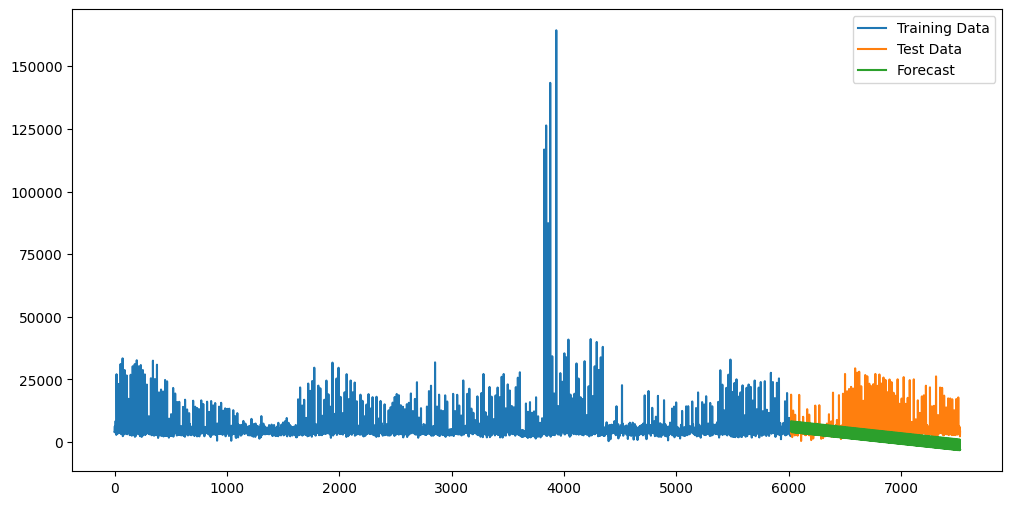

In [82]:
plt.figure(figsize=(12, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Test Data')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()

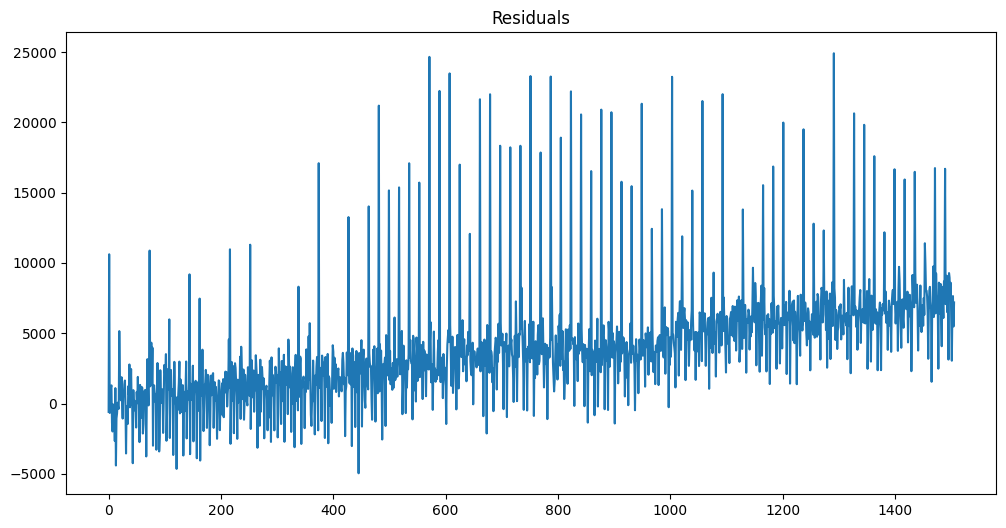

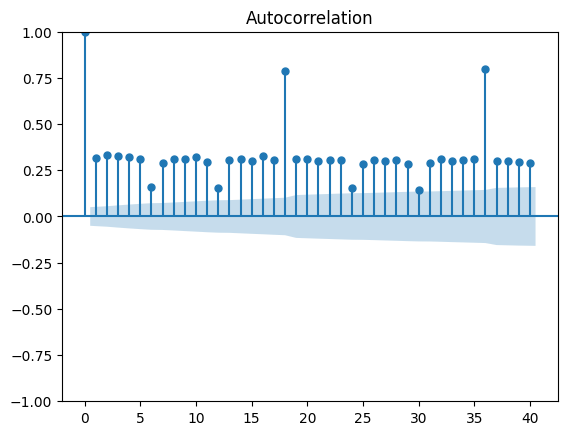

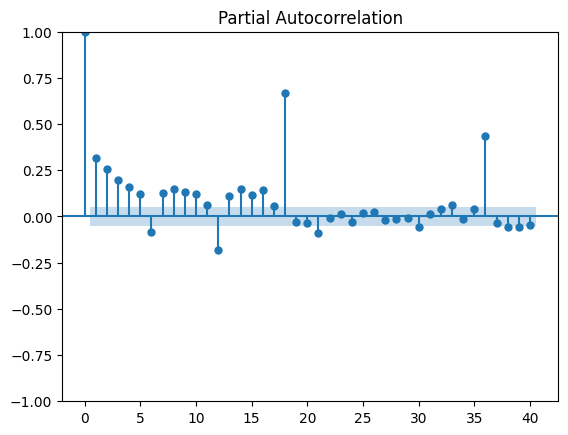

In [83]:
residuals = test_values - forecast
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('Residuals')
plt.show()

import statsmodels.api as sm
sm.graphics.tsa.plot_acf(residuals, lags=40)
sm.graphics.tsa.plot_pacf(residuals, lags=40)
plt.show()

## Random Forest

In [85]:
df_revenue.columns

Index(['Order_DateTime', 'Total_Revenue_Sum'], dtype='object')

In [90]:
# Convert Order_DateTime to datetime
df_revenue['Order_DateTime'] = pd.to_datetime(df_revenue['Order_DateTime'])

# Convert Order_DateTime to numerical values (Unix timestamps)
df_revenue['Order_DateTime'] = df_revenue['Order_DateTime'].astype(int) / 10**9  # to convert to seconds

# Prepare the data for the model
X = df_revenue[['Order_DateTime']]
y = df_revenue['Total_Revenue_Sum']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Random Forest model
RFmodel = RandomForestRegressor(n_estimators=100, random_state=42)
RFmodel.fit(X_train, y_train)

y_pred = RFmodel.predict(X_test)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

In [91]:
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MAPE: {mape}')

RMSE: 4883.06149328658
MAE: 1868.0689658034528
MAPE: 0.32730237249284116


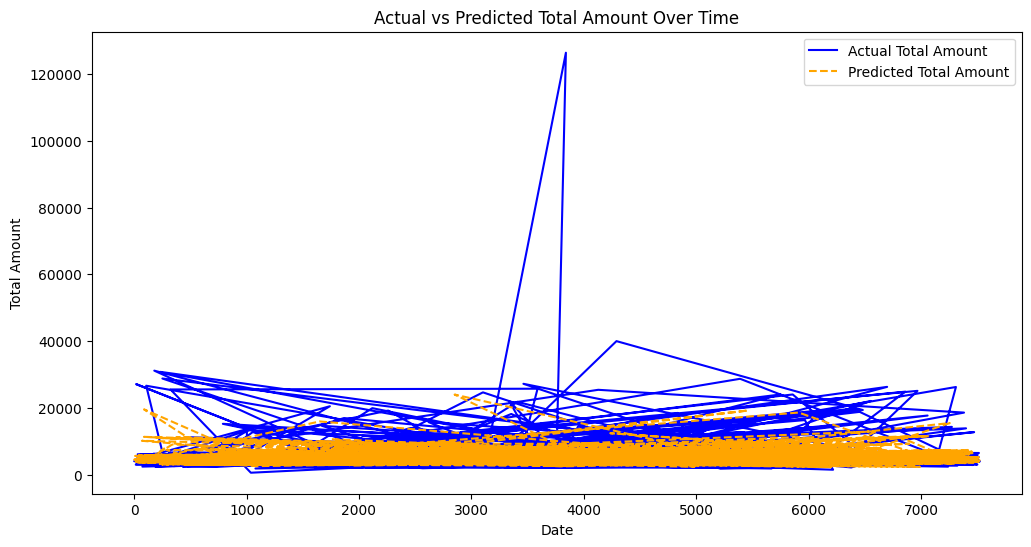

In [92]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Total Amount', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Total Amount', color='orange', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.title('Actual vs Predicted Total Amount Over Time')
plt.legend()
plt.show()

In [99]:
# Convert Order_DateTime to datetime
df_revenue['Order_DateTime'] = pd.to_datetime(df_revenue['Order_DateTime'])

# Extract year, month, day, and hour from Order_DateTime
df_revenue['Year'] = df_revenue['Order_DateTime'].dt.year
df_revenue['Month'] = df_revenue['Order_DateTime'].dt.month
df_revenue['Day'] = df_revenue['Order_DateTime'].dt.day
df_revenue['Hour'] = df_revenue['Order_DateTime'].dt.hour

# Prepare the data for the model with additional features
X = df_revenue[['Year', 'Month', 'Day', 'Hour']]
y = df_revenue['Total_Revenue_Sum']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Random Forest model
RFmodel = RandomForestRegressor(n_estimators=100, random_state=42)
RFmodel.fit(X_train, y_train)

y_pred = RFmodel.predict(X_test)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MAPE: {mape}')

RMSE: 4580.641952126632
MAE: 1696.8092142229523
MAPE: 0.31781433202870607


In [ ]:


# Fit Random Forest model
XGBmodel = XGBRegressor(n_estimators=100, random_state=42)
XGBmodel.fit(X_train, y_train)

y_pred = XGBmodel.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MAPE: {mape}')

RMSE: 4710.568515822294
MAE: 1806.4332298410525
MAPE: 0.3344001621784266


In [95]:
SARIMAXmodel = SARIMAX(train, order=(1, 0, 2), seasonal_order=(1, 1, 1, 6))  # Example seasonal order

# Fit the model
fit = SARIMAXmodel.fit(disp=False)

# Forecast
forecast = fit.forecast(steps=len(test))

# Convert to numpy array for evaluation
forecast = np.array(forecast)
test_values = np.array(test)

# Calculate metrics
rmse = mean_squared_error(test_values, forecast, squared=False)
mae = mean_absolute_error(test_values, forecast)
mape = mean_absolute_percentage_error(test_values, forecast)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MAPE: {mape}')


RMSE: 3218.7805798728796
MAE: 1661.8919138998642
MAPE: 0.3106594386942502


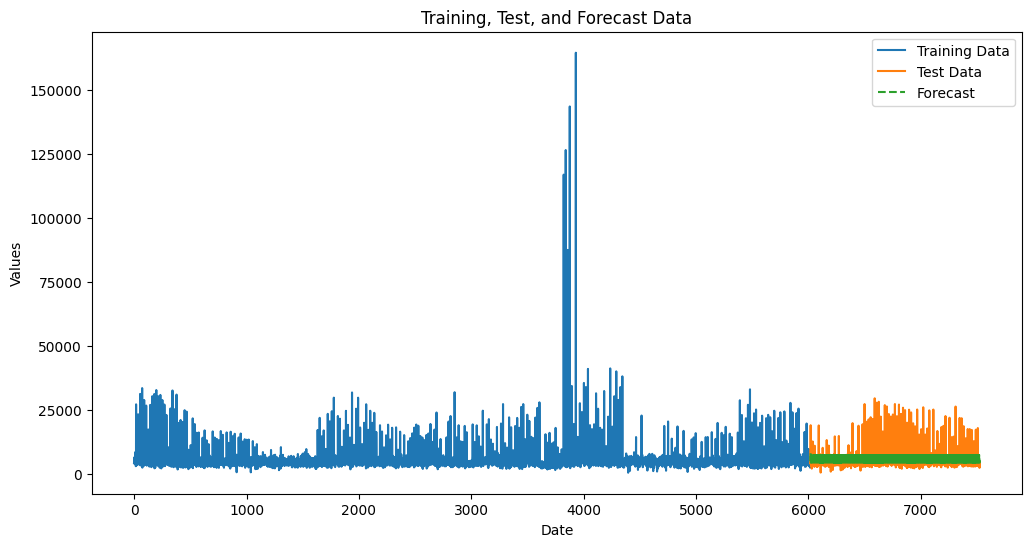

In [96]:
plt.figure(figsize=(12, 6))

# Plot the training data
plt.plot(train, label='Training Data')

# Plot the test data
plt.plot(test, label='Test Data')

# Plot the forecasted values
plt.plot(test.index, forecast, label='Forecast', linestyle='--')

# Add title and labels
plt.title('Training, Test, and Forecast Data')
plt.xlabel('Date')
plt.ylabel('Values')

plt.legend()

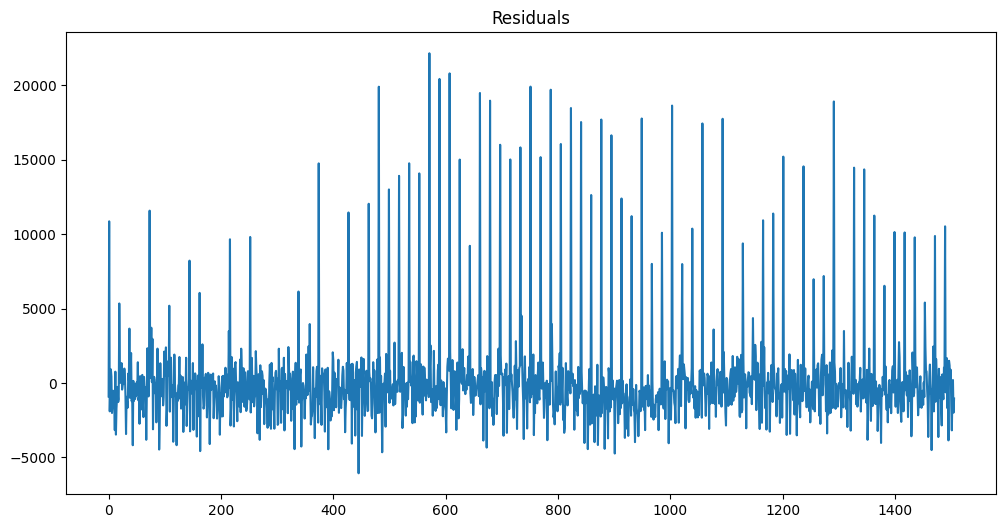

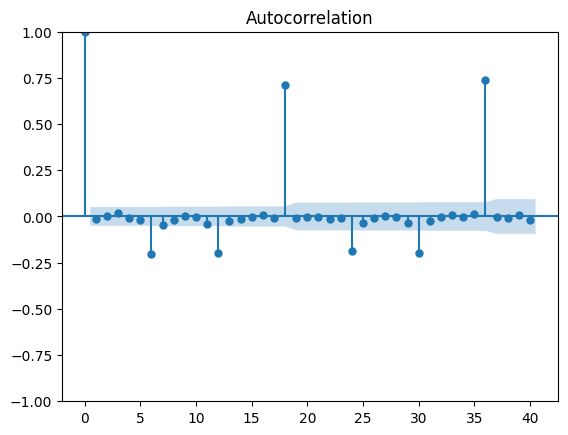

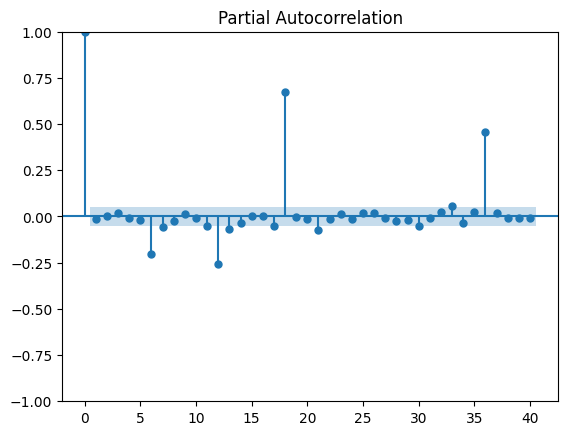

In [97]:
residuals = test_values - forecast
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('Residuals')
plt.show()

import statsmodels.api as sm
sm.graphics.tsa.plot_acf(residuals, lags=40)
sm.graphics.tsa.plot_pacf(residuals, lags=40)
plt.show()

In [ ]:
import pickle

# Define the filename for saving the model
filename = 'my_sarima_model.pkl'

# Serialize and save the model to a file
with open(filename, 'wb') as file:
    pickle.dump(fit, file)


In [ ]:
with open('/content/my_sarima_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [ ]:
forecast_steps = 30
future_values = loaded_model.get_forecast(steps=forecast_steps)
forecast_mean = future_values.predicted_mean
forecast_ci = future_values.conf_int()

print(forecast_mean)
print(forecast_ci)